# This is a sample Jupyter Notebook

Below is an example of a code cell. 
Put your cursor into the cell and press Shift+Enter to execute it and select the next one, or click 'Run Cell' button.

Press Double Shift to search everywhere for classes, files, tool windows, actions, and settings.

To learn more about Jupyter Notebooks in PyCharm, see [help](https://www.jetbrains.com/help/pycharm/ipython-notebook-support.html).
For an overview of PyCharm, go to Help -> Learn IDE features or refer to [our documentation](https://www.jetbrains.com/help/pycharm/getting-started.html).

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import statsmodels.api as sm
from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# Load raw transactions
df = pd.read_excel('RetailCo_Transactions.xlsx', sheet_name='RetailCo_Transactions')

# Check it loaded correctly
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(df.head(3))

Shape: (378346, 43)
Columns: ['Transaction_ID', 'Customer_ID', 'Customer_ID_Valid', 'Product_ID', 'Product_ID_Valid', 'Transaction_Date', 'Year', 'Month(1-12)', 'Quarter(Q1-Q4)', 'Dayofweek(Mon-Sun)', 'Product_Category', 'Quantity', 'Unit_Price', 'Total_Revenue', 'Cost_of_Goods_Sold', 'Gross_Profit', 'Gross_Margin', 'Net_Revenue', 'Revenue_Per_Unit', 'Is_Discounted', 'Discount_Applied', 'Marketing_Channel', 'Customer_Region', 'Shipping_Cost', 'Delivery_Days', 'Customer_Satisfaction_Score', 'Missing Delivery_Date Data', 'Missing  Customer Satisfaction Score', 'Qty-Outlier', 'UnitP-Outlier', 'TotRev_Outlier', 'COGsold-Outlier', 'ShipCo-Outlier', 'CustSatSc-Outlier', 'DiscApplied_Outlier', 'DeliveryDays-Outlier', 'Unnamed: 36', 'Unnamed: 37', 'Unnamed: 38', 'Unnamed: 39', 'Unnamed: 40', 'Unnamed: 41', 'Unnamed: 42']
  Transaction_ID Customer_ID  Customer_ID_Valid Product_ID  Product_ID_Valid  \
0      TXN047627   CUST16448                1.0   PROD1127               1.0   
1      TXN02280

In [11]:
xl = pd.ExcelFile('RetailCo_Transactions.xlsx')
print(xl.sheet_names)

['RetailCo_Transactions', 'KPI Analysis', 'EOQ Model', 'Sheet3', 'Scoredcard', 'Sheet2', 'Sheet1', 'section 4 aggregation', 'Sheet5', 'Sheet4', 'RetailCo_aggregation', '(CLV-weighted a', 'Projected CLV', '80-20 analysis']


In [12]:
df = pd.read_excel('RetailCo_Transactions.xlsx', sheet_name='RetailCo_Transactions')

print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(df.head(3))

Shape: (378346, 43)
Columns: ['Transaction_ID', 'Customer_ID', 'Customer_ID_Valid', 'Product_ID', 'Product_ID_Valid', 'Transaction_Date', 'Year', 'Month(1-12)', 'Quarter(Q1-Q4)', 'Dayofweek(Mon-Sun)', 'Product_Category', 'Quantity', 'Unit_Price', 'Total_Revenue', 'Cost_of_Goods_Sold', 'Gross_Profit', 'Gross_Margin', 'Net_Revenue', 'Revenue_Per_Unit', 'Is_Discounted', 'Discount_Applied', 'Marketing_Channel', 'Customer_Region', 'Shipping_Cost', 'Delivery_Days', 'Customer_Satisfaction_Score', 'Missing Delivery_Date Data', 'Missing  Customer Satisfaction Score', 'Qty-Outlier', 'UnitP-Outlier', 'TotRev_Outlier', 'COGsold-Outlier', 'ShipCo-Outlier', 'CustSatSc-Outlier', 'DiscApplied_Outlier', 'DeliveryDays-Outlier', 'Unnamed: 36', 'Unnamed: 37', 'Unnamed: 38', 'Unnamed: 39', 'Unnamed: 40', 'Unnamed: 41', 'Unnamed: 42']
  Transaction_ID Customer_ID  Customer_ID_Valid Product_ID  Product_ID_Valid  \
0      TXN047627   CUST16448                1.0   PROD1127               1.0   
1      TXN02280

In [13]:
print(df.shape)
print(df['Transaction_ID'].notna().sum())
print(df.head(3))
print(df.tail(3))


(378346, 43)
100000
  Transaction_ID Customer_ID  Customer_ID_Valid Product_ID  Product_ID_Valid  \
0      TXN047627   CUST16448                1.0   PROD1127               1.0   
1      TXN022805   CUST23577                1.0   PROD1127               1.0   
2      TXN084091   CUST17768                1.0   PROD1127               1.0   

      Transaction_Date    Year  Month(1-12)  Quarter(Q1-Q4)  \
0  2022-12-28 00:00:00  2022.0         12.0             4.0   
1  2021-12-25 00:00:00  2021.0         12.0             4.0   
2  2024-06-10 00:00:00  2024.0          6.0             2.0   

   Dayofweek(Mon-Sun)  ... CustSatSc-Outlier  DiscApplied_Outlier  \
0                 3.0  ...               NaN                  NaN   
1                 6.0  ...               NaN                  NaN   
2                 1.0  ...               NaN                  NaN   

   DeliveryDays-Outlier  Unnamed: 36  Unnamed: 37  Unnamed: 38  Unnamed: 39  \
0                   NaN          NaN          NaN 

In [14]:
df = df[df['Transaction_ID'].notna()].reset_index(drop=True)

print(f"Shape after cleaning: {df.shape}")
print(df.head(3))

Shape after cleaning: (100000, 43)
  Transaction_ID Customer_ID  Customer_ID_Valid Product_ID  Product_ID_Valid  \
0      TXN047627   CUST16448                1.0   PROD1127               1.0   
1      TXN022805   CUST23577                1.0   PROD1127               1.0   
2      TXN084091   CUST17768                1.0   PROD1127               1.0   

      Transaction_Date    Year  Month(1-12)  Quarter(Q1-Q4)  \
0  2022-12-28 00:00:00  2022.0         12.0             4.0   
1  2021-12-25 00:00:00  2021.0         12.0             4.0   
2  2024-06-10 00:00:00  2024.0          6.0             2.0   

   Dayofweek(Mon-Sun)  ... CustSatSc-Outlier  DiscApplied_Outlier  \
0                 3.0  ...               NaN                  NaN   
1                 6.0  ...               NaN                  NaN   
2                 1.0  ...               NaN                  NaN   

   DeliveryDays-Outlier  Unnamed: 36  Unnamed: 37  Unnamed: 38  Unnamed: 39  \
0                   NaN          Na

In [15]:
# Aggregate to monthly revenue
df['Transaction_Date'] = pd.to_datetime(df['Transaction_Date'])
df['Year'] = df['Transaction_Date'].dt.year
df['Month'] = df['Transaction_Date'].dt.month

monthly = df.groupby(['Year', 'Month'])['Total_Revenue'].sum().reset_index()
monthly = monthly.sort_values(['Year', 'Month']).reset_index(drop=True)
monthly['Month_Index'] = range(1, len(monthly) + 1)
monthly['Date'] = pd.to_datetime(monthly[['Year', 'Month']].assign(day=1))

print(f"Monthly records: {len(monthly)}")
print(monthly.head(6))
print(monthly.tail(6))

Monthly records: 48
   Year  Month  Total_Revenue  Month_Index       Date
0  2021      1      573471.72            1 2021-01-01
1  2021      2      464509.08            2 2021-02-01
2  2021      3      559353.11            3 2021-03-01
3  2021      4      540067.45            4 2021-04-01
4  2021      5      570524.69            5 2021-05-01
5  2021      6      613375.60            6 2021-06-01
    Year  Month  Total_Revenue  Month_Index       Date
42  2024      7      733426.31           43 2024-07-01
43  2024      8      750479.31           44 2024-08-01
44  2024      9      717230.16           45 2024-09-01
45  2024     10      769873.94           46 2024-10-01
46  2024     11      812538.77           47 2024-11-01
47  2024     12      945024.20           48 2024-12-01


NameError: name 'mticker' is not defined

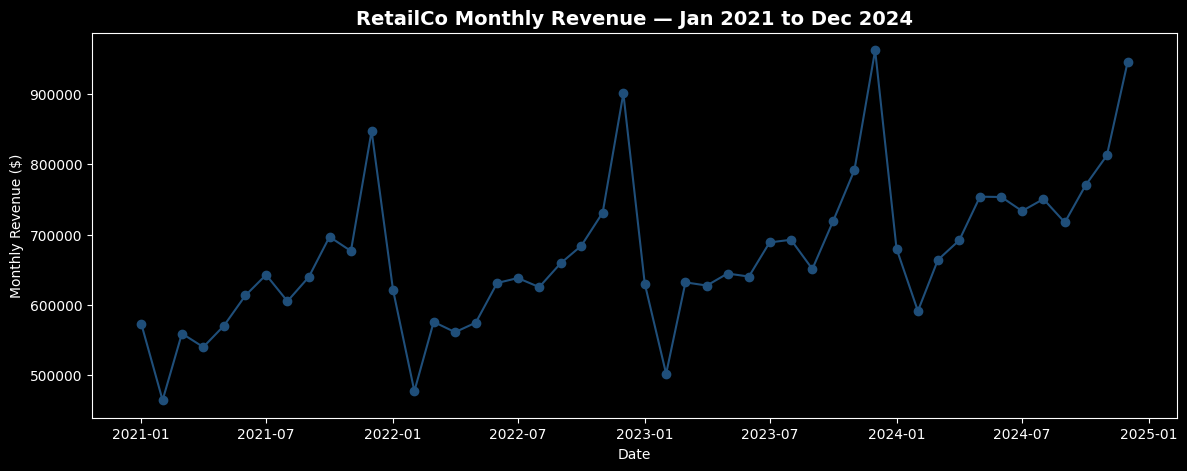

In [16]:
# Set Date as index for time series
ts = monthly.set_index('Date')['Total_Revenue']

# Plot the full time series
plt.figure(figsize=(14, 5))
plt.plot(ts, marker='o', linewidth=1.5, color='#1F4E79')
plt.title('RetailCo Monthly Revenue — Jan 2021 to Dec 2024', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Monthly Revenue ($)')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('monthly_revenue.png', dpi=150)
plt.show()
print("Chart saved")

In [17]:
import matplotlib.ticker as mticker

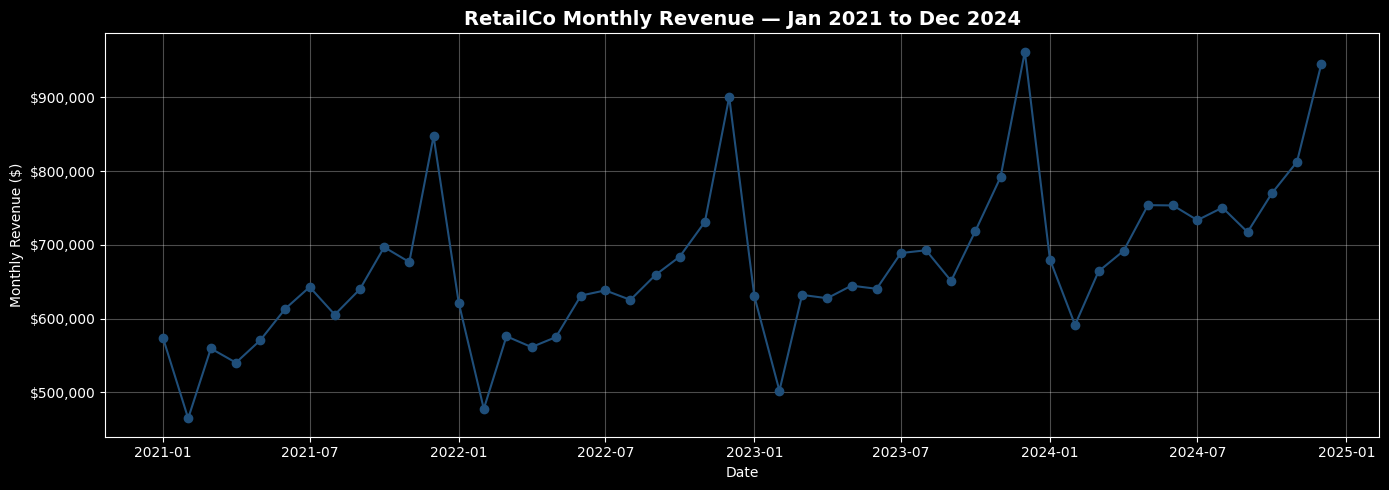

Chart saved


In [18]:
# Set Date as index for time series
ts = monthly.set_index('Date')['Total_Revenue']

# Plot the full time series
plt.figure(figsize=(14, 5))
plt.plot(ts, marker='o', linewidth=1.5, color='#1F4E79')
plt.title('RetailCo Monthly Revenue — Jan 2021 to Dec 2024', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Monthly Revenue ($)')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('monthly_revenue.png', dpi=150)
plt.show()
print("Chart saved")

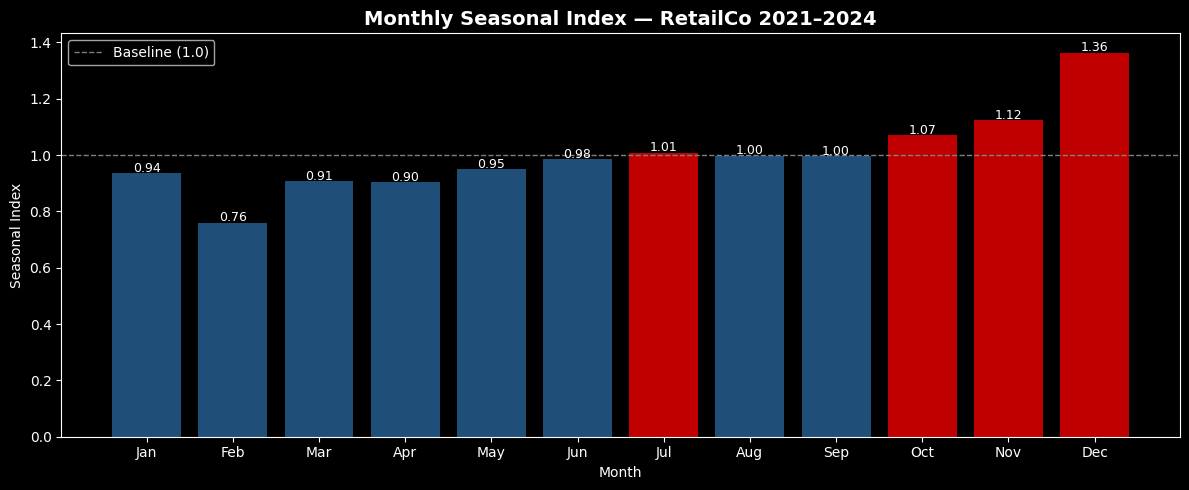

Monthly Seasonal Indices:
  Jan: 0.9351
  Feb: 0.7595
  Mar: 0.9073
  Apr: 0.9034
  May: 0.9493
  Jun: 0.9846
  Jul: 1.0088
  Aug: 0.9977
  Sep: 0.9953
  Oct: 1.0709
  Nov: 1.1241
  Dec: 1.3640

Peak month: Dec (SI = 1.3640)
Off-peak month: Feb (SI = 0.7595)
Seasonal amplitude: 0.6045


In [20]:
# Monthly Seasonal Index
# SI_m = Mean(Revenue in month m across all years) / Overall Monthly Mean

monthly_mean_by_month = monthly.groupby('Month')['Total_Revenue'].mean()
overall_mean = monthly['Total_Revenue'].mean()
seasonal_index = monthly_mean_by_month / overall_mean

month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

# Plot seasonal indices
plt.figure(figsize=(12, 5))
colors = ['#C00000' if si > 1 else '#1F4E79' for si in seasonal_index]
bars = plt.bar(month_names, seasonal_index, color=colors)
plt.axhline(y=1.0, color='gray', linestyle='--', linewidth=1, label='Baseline (1.0)')
plt.title('Monthly Seasonal Index — RetailCo 2021–2024', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Seasonal Index')
plt.legend()
for bar, val in zip(bars, seasonal_index):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.2f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('seasonal_index.png', dpi=150)
plt.show()

# Print values
print("Monthly Seasonal Indices:")
for m, si in zip(month_names, seasonal_index):
    print(f"  {m}: {si:.4f}")

peak = month_names[seasonal_index.argmax()]
offpeak = month_names[seasonal_index.argmin()]
amplitude = seasonal_index.max() - seasonal_index.min()
print(f"\nPeak month: {peak} (SI = {seasonal_index.max():.4f})")
print(f"Off-peak month: {offpeak} (SI = {seasonal_index.min():.4f})")
print(f"Seasonal amplitude: {amplitude:.4f}")

In [21]:
# Quarterly Revenue Heatmap
quarterly = df.groupby(['Year', 'Quarter'])['Total_Revenue'].sum().reset_index()
pivot = quarterly.pivot(index='Year', columns='Quarter', values='Total_Revenue')

fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(pivot.values, cmap='Blues', aspect='auto')

ax.set_xticks(range(4))
ax.set_xticklabels(['Q1', 'Q2', 'Q3', 'Q4'])
ax.set_yticks(range(4))
ax.set_yticklabels(pivot.index)
ax.set_title('Quarterly Revenue Heatmap — RetailCo 2021–2024',
             fontsize=14, fontweight='bold')

for i in range(4):
    for j in range(4):
        val = pivot.values[i, j]
        ax.text(j, i, f'${val:,.0f}', ha='center', va='center',
                fontsize=9, fontweight='bold',
                color='white' if val > pivot.values.max()*0.7 else 'black')

plt.colorbar(im, ax=ax, label='Revenue ($)')
plt.tight_layout()
plt.savefig('quarterly_heatmap.png', dpi=150)
plt.show()
print("Heatmap saved")

KeyError: 'Quarter'

In [22]:
print(df.columns.tolist())

['Transaction_ID', 'Customer_ID', 'Customer_ID_Valid', 'Product_ID', 'Product_ID_Valid', 'Transaction_Date', 'Year', 'Month(1-12)', 'Quarter(Q1-Q4)', 'Dayofweek(Mon-Sun)', 'Product_Category', 'Quantity', 'Unit_Price', 'Total_Revenue', 'Cost_of_Goods_Sold', 'Gross_Profit', 'Gross_Margin', 'Net_Revenue', 'Revenue_Per_Unit', 'Is_Discounted', 'Discount_Applied', 'Marketing_Channel', 'Customer_Region', 'Shipping_Cost', 'Delivery_Days', 'Customer_Satisfaction_Score', 'Missing Delivery_Date Data', 'Missing  Customer Satisfaction Score', 'Qty-Outlier', 'UnitP-Outlier', 'TotRev_Outlier', 'COGsold-Outlier', 'ShipCo-Outlier', 'CustSatSc-Outlier', 'DiscApplied_Outlier', 'DeliveryDays-Outlier', 'Unnamed: 36', 'Unnamed: 37', 'Unnamed: 38', 'Unnamed: 39', 'Unnamed: 40', 'Unnamed: 41', 'Unnamed: 42', 'Month']


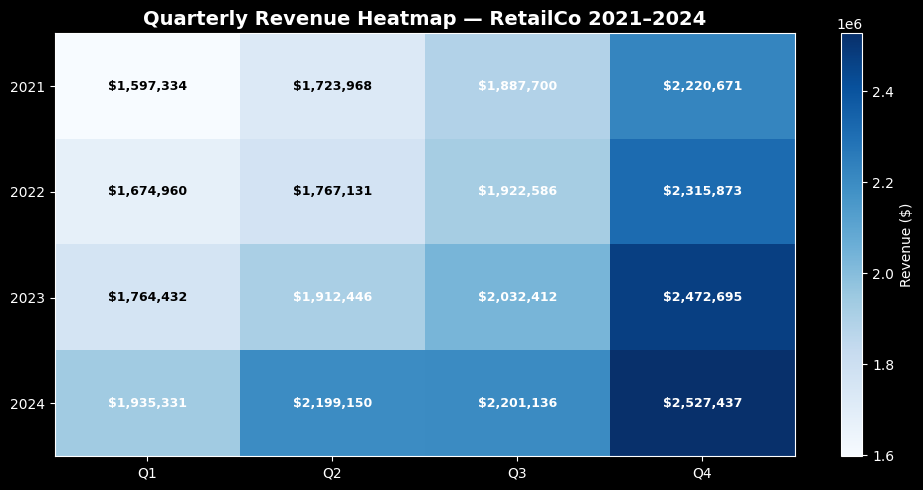

Heatmap saved


In [23]:
# Quarterly Revenue Heatmap
quarterly = df.groupby(['Year', 'Quarter(Q1-Q4)'])['Total_Revenue'].sum().reset_index()
pivot = quarterly.pivot(index='Year', columns='Quarter(Q1-Q4)', values='Total_Revenue')

fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(pivot.values, cmap='Blues', aspect='auto')

ax.set_xticks(range(4))
ax.set_xticklabels(['Q1', 'Q2', 'Q3', 'Q4'])
ax.set_yticks(range(4))
ax.set_yticklabels(pivot.index)
ax.set_title('Quarterly Revenue Heatmap — RetailCo 2021–2024',
             fontsize=14, fontweight='bold')

for i in range(4):
    for j in range(4):
        val = pivot.values[i, j]
        ax.text(j, i, f'${val:,.0f}', ha='center', va='center',
                fontsize=9, fontweight='bold',
                color='white' if val > pivot.values.max()*0.7 else 'black')

plt.colorbar(im, ax=ax, label='Revenue ($)')
plt.tight_layout()
plt.savefig('quarterly_heatmap.png', dpi=150)
plt.show()
print("Heatmap saved")

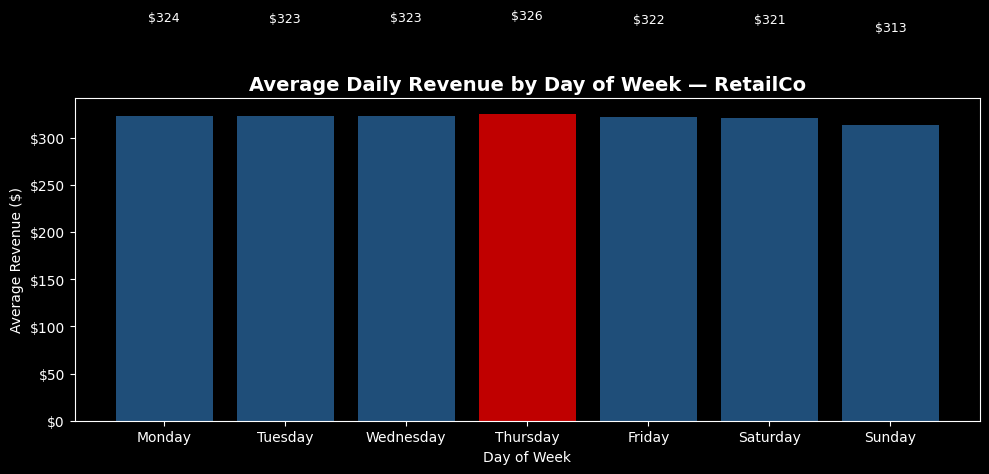

      Day  Total_Revenue
   Monday     323.701392
  Tuesday     323.060836
Wednesday     323.459251
 Thursday     325.790916
   Friday     322.021742
 Saturday     321.110393
   Sunday     313.487164


In [24]:
# Day of week pattern
df['DayOfWeek'] = pd.to_datetime(df['Transaction_Date']).dt.dayofweek
dow_revenue = df.groupby('DayOfWeek')['Total_Revenue'].mean().reset_index()
dow_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_revenue['Day'] = dow_names

plt.figure(figsize=(10, 5))
colors = ['#C00000' if x == dow_revenue['Total_Revenue'].max() else '#1F4E79'
          for x in dow_revenue['Total_Revenue']]
bars = plt.bar(dow_revenue['Day'], dow_revenue['Total_Revenue'], color=colors)
plt.title('Average Daily Revenue by Day of Week — RetailCo', fontsize=14, fontweight='bold')
plt.xlabel('Day of Week')
plt.ylabel('Average Revenue ($)')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
for bar, val in zip(bars, dow_revenue['Total_Revenue']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
             f'${val:,.0f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('dow_revenue.png', dpi=150)
plt.show()
print(dow_revenue[['Day', 'Total_Revenue']].to_string(index=False))

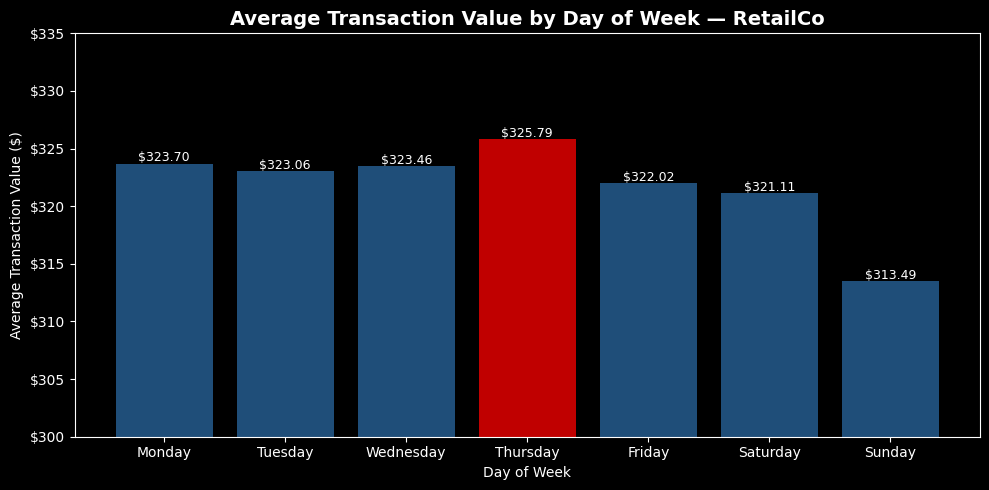

In [25]:
# Day of week pattern - average revenue per transaction
df['DayOfWeek'] = pd.to_datetime(df['Transaction_Date']).dt.dayofweek
dow_revenue = df.groupby('DayOfWeek')['Total_Revenue'].mean().reset_index()
dow_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_revenue['Day'] = dow_names

plt.figure(figsize=(10, 5))
colors = ['#C00000' if x == dow_revenue['Total_Revenue'].max() else '#1F4E79'
          for x in dow_revenue['Total_Revenue']]
bars = plt.bar(dow_revenue['Day'], dow_revenue['Total_Revenue'], color=colors)
plt.title('Average Transaction Value by Day of Week — RetailCo', fontsize=14, fontweight='bold')
plt.xlabel('Day of Week')
plt.ylabel('Average Transaction Value ($)')
plt.ylim(300, 335)
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
for bar, val in zip(bars, dow_revenue['Total_Revenue']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f'${val:,.2f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('dow_revenue.png', dpi=150)
plt.show()

In [26]:
# Split data - Training = first 42 months, Test = last 6 months
train = monthly.iloc[:42]['Total_Revenue'].values
test = monthly.iloc[42:]['Total_Revenue'].values
train_dates = monthly.iloc[:42]['Date']
test_dates = monthly.iloc[42:]['Date']

print(f"Training set: {len(train)} months (Jan 2021 — Jun 2024)")
print(f"Test set: {len(test)} months (Jul 2024 — Dec 2024)")
print(f"\nTest actuals:")
for d, v in zip(test_dates, test):
    print(f"  {d.strftime('%b %Y')}: ${v:,.2f}")

Training set: 42 months (Jan 2021 — Jun 2024)
Test set: 6 months (Jul 2024 — Dec 2024)

Test actuals:
  Jul 2024: $733,426.31
  Aug 2024: $750,479.31
  Sep 2024: $717,230.16
  Oct 2024: $769,873.94
  Nov 2024: $812,538.77
  Dec 2024: $945,024.20


In [27]:
# Model 1 — Exponential Smoothing (Holt-Winters)
model1 = ExponentialSmoothing(
    train,
    trend='add',
    seasonal='add',
    seasonal_periods=12
).fit()

pred1 = model1.forecast(6)

print("Model 1 — Exponential Smoothing Predictions:")
for d, actual, pred in zip(test_dates, test, pred1):
    print(f"  {d.strftime('%b %Y')}: Actual=${actual:,.2f} | Predicted=${pred:,.2f}")

Model 1 — Exponential Smoothing Predictions:
  Jul 2024: Actual=$733,426.31 | Predicted=$783,821.89
  Aug 2024: Actual=$750,479.31 | Predicted=$772,150.71
  Sep 2024: Actual=$717,230.16 | Predicted=$793,249.59
  Oct 2024: Actual=$769,873.94 | Predicted=$846,817.59
  Nov 2024: Actual=$812,538.77 | Predicted=$880,855.08
  Dec 2024: Actual=$945,024.20 | Predicted=$1,056,764.22


In [28]:
# Model 2 — OLS Regression with Trend + Seasonal Dummies
# Create features for all 48 months
t = np.arange(1, 49)
months = monthly['Month'].values

# Create seasonal dummy variables (11 dummies, January is baseline)
seasonal_dummies = pd.get_dummies(months, prefix='M', drop_first=True).astype(int).values

# Combine trend + seasonal dummies
X = np.column_stack([t, seasonal_dummies])
X = sm.add_constant(X)
y = monthly['Total_Revenue'].values

# Split
X_train = X[:42]
X_test = X[42:]
y_train = y[:42]

# Fit OLS
model2 = sm.OLS(y_train, X_train).fit()
pred2 = model2.predict(X_test)

print("Model 2 — OLS Regression Predictions:")
for d, actual, pred in zip(test_dates, test, pred2):
    print(f"  {d.strftime('%b %Y')}: Actual=${actual:,.2f} | Predicted=${pred:,.2f}")

Model 2 — OLS Regression Predictions:
  Jul 2024: Actual=$733,426.31 | Predicted=$739,147.59
  Aug 2024: Actual=$750,479.31 | Predicted=$723,598.08
  Sep 2024: Actual=$717,230.16 | Predicted=$732,520.02
  Oct 2024: Actual=$769,873.94 | Predicted=$782,489.44
  Nov 2024: Actual=$812,538.77 | Predicted=$815,736.97
  Dec 2024: Actual=$945,024.20 | Predicted=$985,886.26


In [29]:
# Model 3 — Ridge Regression with Polynomial Trend
t_all = np.arange(1, 49).reshape(-1, 1)

# Create polynomial features (degree 2)
poly = PolynomialFeatures(degree=2)
t_poly = poly.fit_transform(t_all)

# Split
t_poly_train = t_poly[:42]
t_poly_test = t_poly[42:]

# Fit Ridge Regression
model3 = Ridge(alpha=1.0)
model3.fit(t_poly_train, y_train)
pred3 = model3.predict(t_poly_test)

print("Model 3 — Ridge Regression Predictions:")
for d, actual, pred in zip(test_dates, test, pred3):
    print(f"  {d.strftime('%b %Y')}: Actual=${actual:,.2f} | Predicted=${pred:,.2f}")

Model 3 — Ridge Regression Predictions:
  Jul 2024: Actual=$733,426.31 | Predicted=$728,444.53
  Aug 2024: Actual=$750,479.31 | Predicted=$731,115.61
  Sep 2024: Actual=$717,230.16 | Predicted=$733,729.62
  Oct 2024: Actual=$769,873.94 | Predicted=$736,286.54
  Nov 2024: Actual=$812,538.77 | Predicted=$738,786.37
  Dec 2024: Actual=$945,024.20 | Predicted=$741,229.13


In [30]:
# Model Evaluation — MAPE, RMSE, MAD
def mape(actual, predicted):
    return np.mean(np.abs((actual - predicted) / actual)) * 100

def rmse(actual, predicted):
    return np.sqrt(mean_squared_error(actual, predicted))

def mad(actual, predicted):
    return mean_absolute_error(actual, predicted)

models = {
    'Exponential Smoothing': pred1,
    'OLS Regression': pred2,
    'Ridge Regression': pred3
}

print("=" * 55)
print(f"{'Model':<25} {'MAPE':>8} {'RMSE':>12} {'MAD':>10}")
print("=" * 55)
for name, pred in models.items():
    m = mape(test, pred)
    r = rmse(test, pred)
    d = mad(test, pred)
    print(f"{name:<25} {m:>7.2f}% {r:>12,.2f} {d:>10,.2f}")
print("=" * 55)

Model                         MAPE         RMSE        MAD
Exponential Smoothing        8.43%    72,871.57  67,514.40
OLS Regression               2.14%    21,710.98  17,428.02
Ridge Regression             6.76%    90,159.09  58,663.30


In [31]:
# 6-month forward forecast Jan-Jun 2025 using OLS
future_t = np.arange(49, 55)
future_months = [1, 2, 3, 4, 5, 6]
future_dates = pd.date_range('2025-01-01', periods=6, freq='MS')

# Create feature matrix for future periods
future_seasonal = pd.get_dummies(future_months, prefix='M', drop_first=True).astype(int)

# Align columns with training dummies
train_cols = pd.get_dummies(monthly['Month'].values[:42], prefix='M', drop_first=True).columns
for col in train_cols:
    if col not in future_seasonal.columns:
        future_seasonal[col] = 0
future_seasonal = future_seasonal[train_cols]

X_future = np.column_stack([future_t, future_seasonal.values])
X_future = sm.add_constant(X_future, has_constant='add')

# Get predictions with confidence intervals
pred_result = model2.get_prediction(X_future)
forecast = pred_result.predicted_mean
ci = pred_result.conf_int(alpha=0.05)

print("6-Month Forward Forecast (Jan-Jun 2025):")
print(f"{'Month':<12} {'Forecast':>12} {'Lower 95%':>12} {'Upper 95%':>12}")
print("-" * 50)
for d, f, lo, hi in zip(future_dates, forecast, ci[:, 0], ci[:, 1]):
    print(f"{d.strftime('%b %Y'):<12} ${f:>11,.2f} ${lo:>11,.2f} ${hi:>11,.2f}")

6-Month Forward Forecast (Jan-Jun 2025):
Month            Forecast    Lower 95%    Upper 95%
--------------------------------------------------
Jan 2025     $ 729,601.83 $ 696,405.02 $ 762,798.63
Feb 2025     $ 612,022.97 $ 578,826.16 $ 645,219.77
Mar 2025     $ 711,014.38 $ 677,817.58 $ 744,211.19
Apr 2025     $ 708,396.16 $ 675,199.35 $ 741,592.96
May 2025     $ 739,133.58 $ 705,936.78 $ 772,330.39
Jun 2025     $ 762,768.96 $ 729,572.16 $ 795,965.77


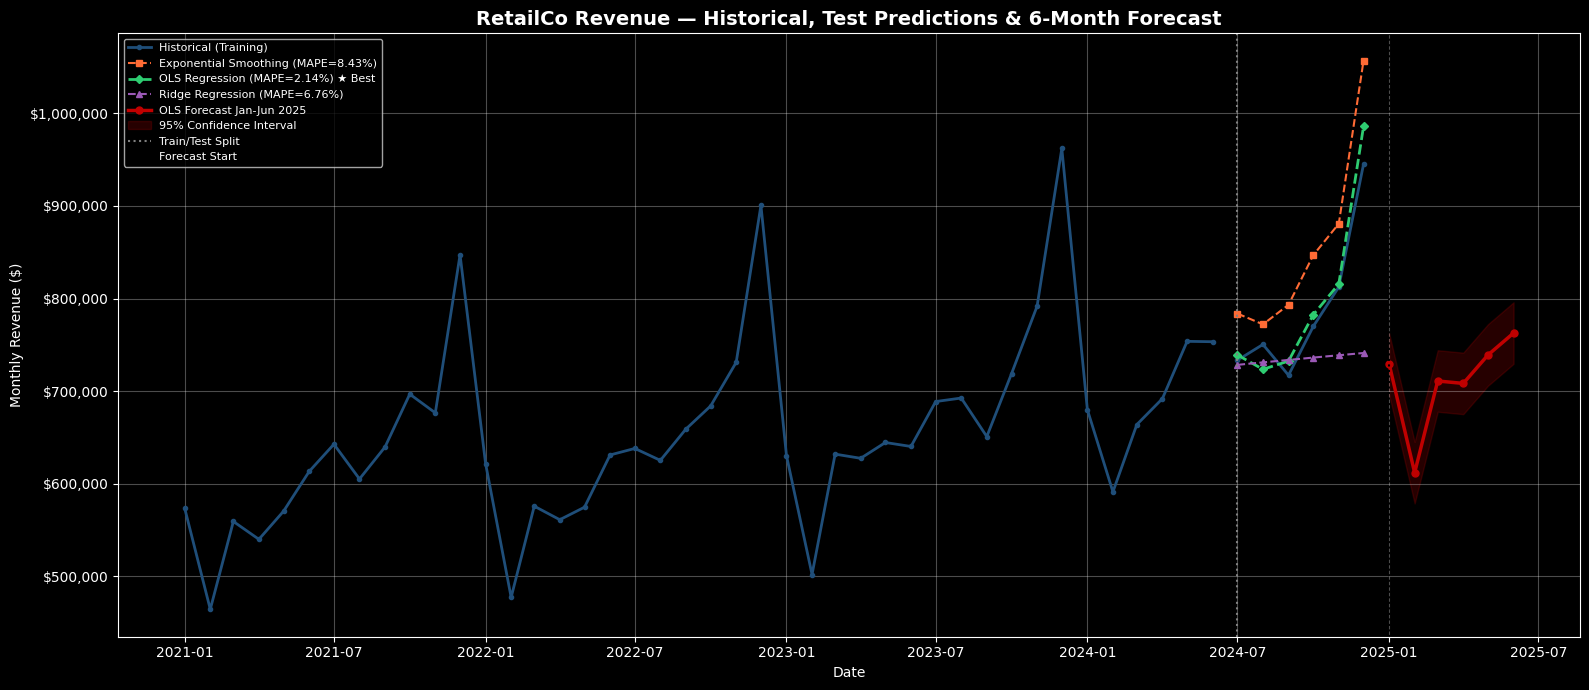

Final forecast chart saved


In [32]:
# Final visualization - historical + test predictions + forecast
fig, ax = plt.subplots(figsize=(16, 7))

# Historical training data
ax.plot(train_dates, train, color='#1F4E79', linewidth=2, label='Historical (Training)', marker='o', markersize=3)

# Test actuals
ax.plot(test_dates, test, color='#1F4E79', linewidth=2, marker='o', markersize=3)

# Test predictions - all 3 models
ax.plot(test_dates, pred1, color='#FF6B35', linewidth=1.5, linestyle='--', label='Exponential Smoothing (MAPE=8.43%)', marker='s', markersize=4)
ax.plot(test_dates, pred2, color='#2ECC71', linewidth=2, linestyle='--', label='OLS Regression (MAPE=2.14%) ★ Best', marker='D', markersize=4)
ax.plot(test_dates, pred3, color='#9B59B6', linewidth=1.5, linestyle='--', label='Ridge Regression (MAPE=6.76%)', marker='^', markersize=4)

# Forward forecast
ax.plot(future_dates, forecast, color='#C00000', linewidth=2.5, linestyle='-', label='OLS Forecast Jan-Jun 2025', marker='o', markersize=5)

# Confidence interval shading
ax.fill_between(future_dates, ci[:, 0], ci[:, 1], alpha=0.2, color='#C00000', label='95% Confidence Interval')

# Vertical lines separating periods
ax.axvline(x=pd.Timestamp('2024-07-01'), color='gray', linestyle=':', linewidth=1.5, label='Train/Test Split')
ax.axvline(x=pd.Timestamp('2025-01-01'), color='black', linestyle=':', linewidth=1.5, label='Forecast Start')

ax.set_title('RetailCo Revenue — Historical, Test Predictions & 6-Month Forecast', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Monthly Revenue ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend(loc='upper left', fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('forecast_final.png', dpi=150, bbox_inches='tight')
plt.show()
print("Final forecast chart saved")